# **Intro to Graph Theory - Colab. 08.05.2026**

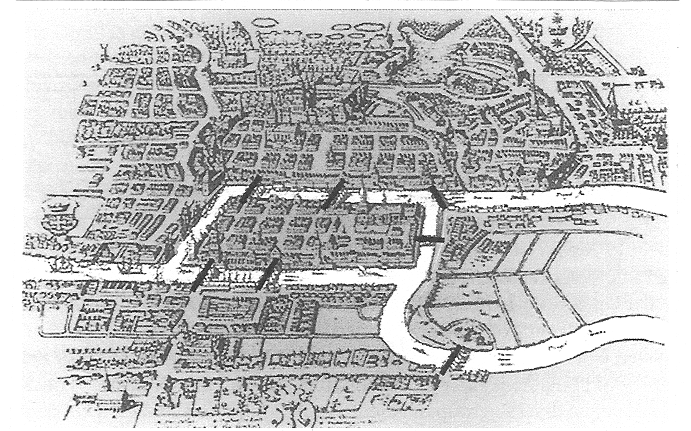

NetworkX is one of the most frequently used Python packages to create, manipulate, and mine graphs.

With NetworkX you can load and store networks in standard and nonstandard data formats, generate many types of random and classic networks, analyze network structure, build network models, design new network algorithms, draw networks, and much more.

Library documentation: <a>https://networkx.org/documentation/stable/</a> .



# Setup

In [1]:
# Import the NetworkX package and some other may-be-useful packages
import itertools
import copy
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random as rnd

# Euler's Algorithm

## Seven Bridges of Königsberg

What you are seeing below is the beautiful old town of Königsberg which is famous for its seven bridges. Each of these bridges either connect two large islands — Kneiphof and Lomse — or two mainland portions of the city.




What gave the town its fame is a question that was asked to mathematician Leonhard Euler almost 300 years ago:

> ***Can you take a walk through Königsberg visiting each mass by crossing each bridge once and only once?***

Euler's negative resolution to this question laid the foundations of graph theory. Before diving into Euler's solution, let's reformulate the problem.

### Reformulating the Problem in Abstract Terms

In order to have a clear look, we should first simplify the map a little.



Euler observed that the choice of route inside each land mass is irrelevant. The only thing that matters is the sequence of bridges to be crossed. This observation allows us to abstract the problem even more. In the graph below, blue vertices represent the land masses and edges represent the bridges that connect them.

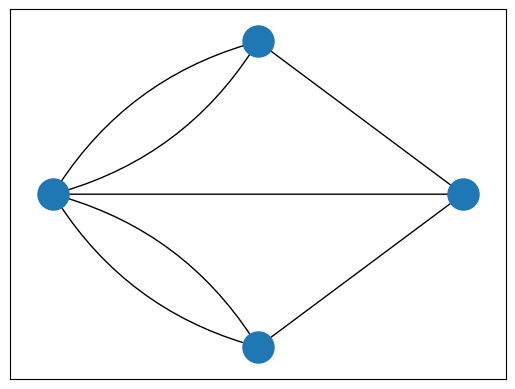

In [2]:
# Create graph
G = nx.DiGraph()
G.add_edge("A", "B", label="a")
G.add_edge("B", "A", label="b")
G.add_edge("A", "C", label="c")
G.add_edge("C", "A", label="d")
G.add_edge("A", "D", label="e")
G.add_edge("B", "D", label="f")
G.add_edge("C", "D", label="g")

positions = {"A": (0, 0), "B": (1, -2), "C": (1, 2), "D": (2, 0)}

# Visualize graph
nx.draw_networkx_nodes(G, pos=positions, node_size=500)
nx.draw_networkx_edges(
    G, pos=positions, edgelist=[("A", "D"), ("B", "D"), ("C", "D")], arrowstyle="-"
)
nx.draw_networkx_edges(
    G,
    pos=positions,
    edgelist=[("A", "B"), ("B", "A"), ("C", "A"), ("A", "C")],
    arrowstyle="-",
    connectionstyle="arc3,rad=0.2",
);

Based on this abstraction, we can paraphrase the problem as follows:

> ***Can you draw the above graph without lifting your pen or crossing on a line more than once?***

If you can, it means there is an ***Euler Path*** in the graph. If this path starts and ends at the same blue circle, it is called an ***Euler Circuit***.

Note that every Euler Circuit is also an Euler Path.

### Euler's Method

Euler denoted land masses of the town by capital letters $A$, $B$, $C$ and $D$ and bridges by lowercase $a$, $b$, $c$, $d$, $e$, $f$ and $g$. Let's draw the graph based on this node and edge labels.

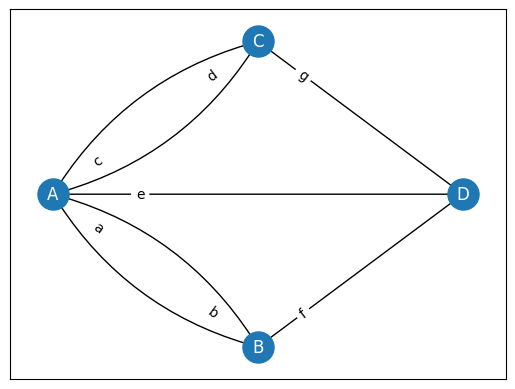

In [3]:
# Design and draw graph
edge_labels = nx.get_edge_attributes(G, "label")

nx.draw_networkx_nodes(G, pos=positions, node_size=500)
nx.draw_networkx_labels(G, pos=positions, font_color="w")
nx.draw_networkx_edges(
    G, pos=positions, edgelist=[("A", "D"), ("B", "D"), ("C", "D")], arrowstyle="-"
)
nx.draw_networkx_edges(
    G,
    pos=positions,
    edgelist=[("A", "B"), ("B", "A"), ("C", "A"), ("A", "C")],
    arrowstyle="-",
    connectionstyle="arc3,rad=0.2",
)
nx.draw_networkx_edge_labels(G, pos=positions, edge_labels=edge_labels, label_pos=0.2);

He described his logic as follows:
- If we cross bridge $a$, we walk from $A$ to $B$. In this case, our travel route is denoted as $AB$.
- If we cross first $a$ and then $f$, our route will be $ABD$.
- So, sequential use of $n$ bridges is denoted with $n+1$ capital letters.
- Since we need to cross each of 7 bridges, our route should consist of a sequence of $A$, $B$, $C$ and $D$ of length 8.

He also stated the fact that number of appearances of each land mass in the route depend on the number of bridges it has.
- $A$ has 5 bridges. All these 5 bridges should appear in our Euler Path exactly once. Then, $A$ should appear in our route for 3 times.
- $B$ has 3 bridges. It should appear in the route for 2 times.
- $C$ has 3 bridges. It should appear in the route for 2 times.
- $D$ has 3 bridges. It should appear in the route for 2 times.
- Then, the total length of the route should be 3 + 2 + 2 + 2 = 9.

It is obvious that we cannot satisfy both of these conditions at the same time. Therefore, Euler concluded that there is no solution to Seven Bridges of Königsberg problem (I.e. Königsberg does not have an Euler Path).

### Generalizing Euler's Solution

Euler generalized the method he applied for Königsberg problem as follows:

> ***A graph has an Euler Path if and only if the number of vertices with odd degree is either zero or two.***

- If there are two vertices with odd degree, then they are the starting and ending vertices.
- If there are no vertices with odd degree, any vertex can be starting or ending vertex and the graph has also an Euler Circuit.

## Euler's Algorithm in NetworkX

https://networkx.org/documentation/stable/reference/algorithms/euler.html

NetworkX implements several methods using the Euler's algorithm. These are:
- **is_eulerian**      : Whether the graph has an Eulerian circuit
- **eulerian_circuit** : Sequence of edges of an Eulerian circuit in the graph.
- **eulerize**         : Transforms a graph into an Eulerian graph
- **is_semieulerian**  : Whether the graph has an Eulerian path but not an Eulerian circuit.
- **has_eulerian_path**: Whether the graph has an Eulerian path.
- **eulerian_path**    : Sequence of edges of in Eulerian path in the graph.

In this part, we will briefly explain the NetworkX implementation of Euler's algorithm by explaining some of these methods.

**Note**: NetworkX implementation does not allow graphs with isolated nodes to have Eulerian Path and/or Eulerian Circuit. Thus, an Eulerian Path or Eulerian Circuit must visit not only all edges, but also all vertices of the graph.

### 1. Eulerian Circuit Implementation

Implementation of the `is_eulerian` method is quite simple. In order to have an Euler circuit (i.e. to be Eulerian):
- A directed graph must be strongly connected and every vertex of it must have equal in degree and out degree.
- An undirected graph must be connected, and it must have no vertices of odd degree.

Here is an example:

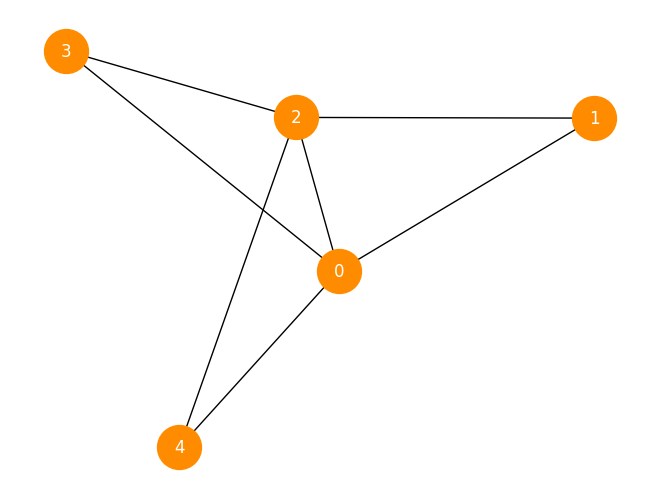

In [4]:
T = nx.Graph([(0, 1), (0, 2), (0, 3), (0, 4), (1, 2), (2, 3), (2, 4)])
nx.draw(
    T, with_labels=True, node_size=1000, font_color="White", node_color="darkorange"
)

In [5]:
nx.is_eulerian(T)

True

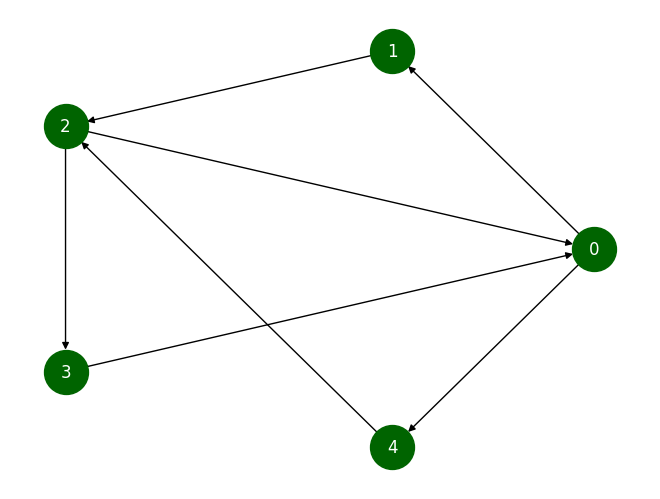

In [6]:
F = nx.DiGraph([(0, 1), (1, 2), (2, 3), (3, 0), (0, 4), (4, 2), (2, 0)])
nx.draw(
    F, with_labels=True, node_size=1000, font_color="White", node_color="darkgreen", pos = nx.circular_layout(F)
)

In [7]:
nx.is_eulerian(F)

True

NetworkX has also implemented the `eulerian_circuit` method to determine sequence of edges that consist of a Euler Circuit.

If an undirected graph is not Eulerian, it can still be `semi_eulerian` meaning that it might have an Eulerian Path with different starting and ending vertices. As explained above, this is possible if and only if
- there are exactly two vertices of odd degree, and
- all of its vertices belong to a single connected component.

If source vertex is given by the user, it must have an odd degree. Otherwise, there cannot be an Eulerian Path starting from the given source.

**Theorem 1**

*A connected undirected multigraph with at least two vertices has an Euler circuit if and only if each of its vertices has even degree.*

**Theorem 2**

*A connected undirected multigraph has an Euler path but not an Euler circuit if and only if it has exactly two vertices of odd degree.*


In [ ]:
#To get an Eulerian circuit in an undirected graph:
list(nx.eulerian_circuit(T))

[(0, 4), (4, 2), (2, 3), (3, 0), (0, 2), (2, 1), (1, 0)]

In [ ]:
list(nx.eulerian_circuit(T, source=1))

[(1, 2), (2, 4), (4, 0), (0, 3), (3, 2), (2, 0), (0, 1)]

In [ ]:
# To get the sequence of vertices in an Eulerian circuit:

[u for u, v in nx.eulerian_circuit(T)]

[0, 4, 2, 3, 0, 2, 1]

# Exercise 1.

1. Which of the undirected graphs  have an Euler circuit? Of those that do not, which have an Euler path?

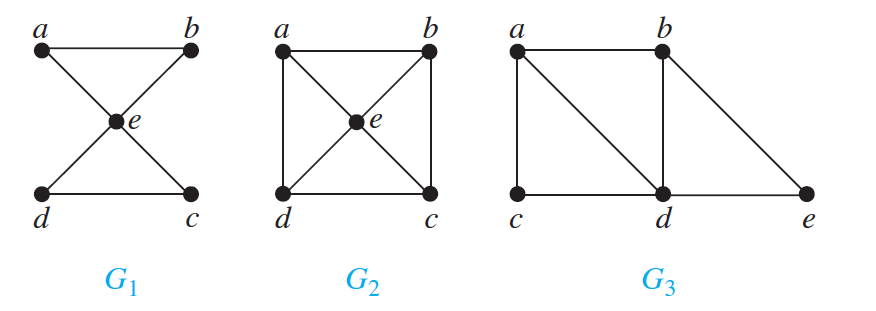

2. Which of the directed graphs  have an Euler circuit? Of those that do not, which have an Euler path?

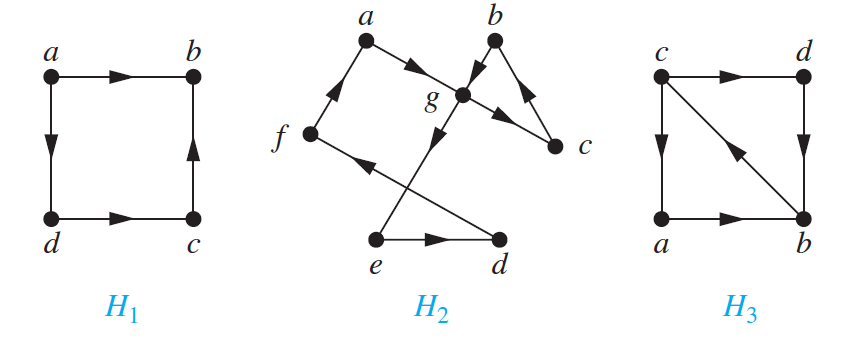

3. Check you answers with a Python code:
  * create the graph in Python;
  * find if the graph is eulerian or semi_eulerian with the is_eulerian or semi_eulerian methods;
  * get an Eulerian circuit in the graph.


Graph G₁ Analysis:
Connected: Yes
Vertex degrees: {'a': 2, 'b': 2, 'c': 2, 'd': 2}
Odd degree vertices: []
Number of odd degree vertices: 0

🏆 Classification: Eulerian - Has Euler circuit


C:\Users\swj17\AppData\Local\Temp\ipykernel_23316\205141166.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


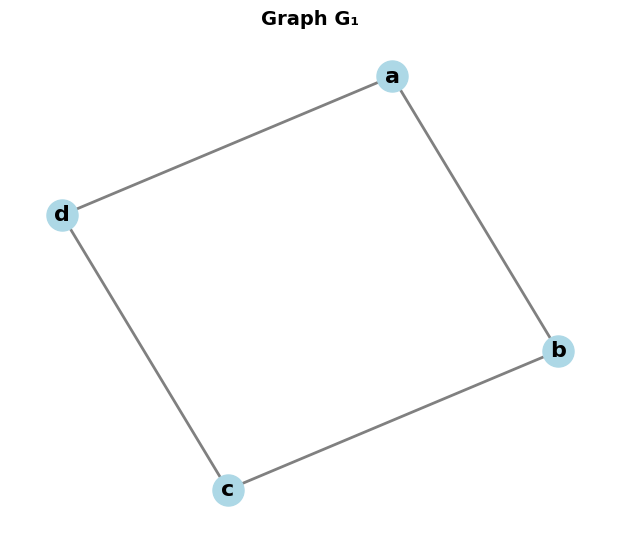


📋 Finding Euler path/circuit:
   ✓ Found Euler circuit (length: 4 edges):
      a → d → c → b → a

Graph G₂ Analysis:
Connected: Yes
Vertex degrees: {'a': 4, 'b': 3, 'c': 3, 'd': 3, 'e': 3}
Odd degree vertices: ['b', 'c', 'd', 'e']
Number of odd degree vertices: 4

🏆 Classification: Neither - No Euler circuit or path


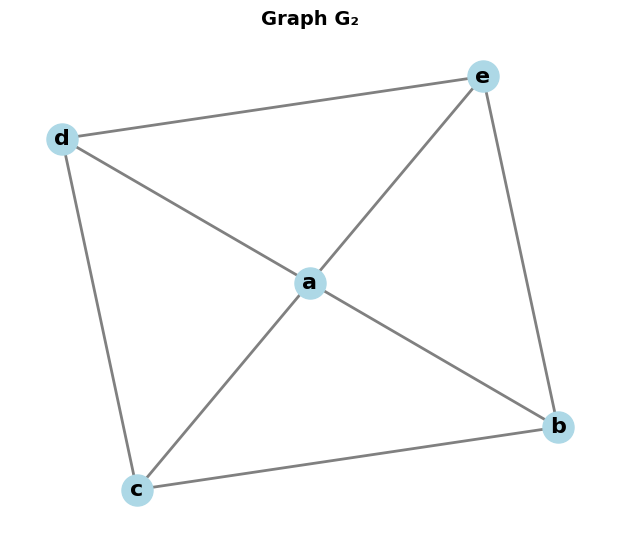


📋 Finding Euler path/circuit:
   ✗ No Euler path or circuit exists

Graph G₃ Analysis:
Connected: Yes
Vertex degrees: {'a': 3, 'b': 2, 'c': 4, 'd': 2, 'e': 3, 'f': 2}
Odd degree vertices: ['a', 'e']
Number of odd degree vertices: 2

🏆 Classification: Semi-Eulerian - Has Euler path but no circuit


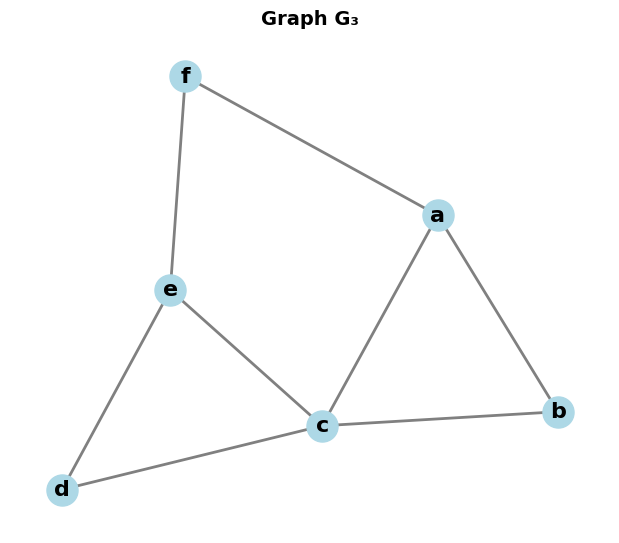


📋 Finding Euler path/circuit:
   ✗ Unable to find Euler circuit

📊 Summary Table
Graph      Classification                      # Odd Degree Vertices
------------------------------------------------------------
Graph G₁   Eulerian                            0              
Graph G₂   Neither                             4              
Graph G₃   Eulerian                            3              


In [12]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graph G1 (4 vertices forming a cycle - all vertices have even degree)
G1 = nx.Graph()
G1.add_edges_from([('a', 'b'), ('b', 'c'), ('c', 'd'), ('d', 'a')])

# Create graph G2 (5 vertices - has 4 vertices with odd degree)
G2 = nx.Graph()
G2.add_edges_from([('a', 'b'), ('a', 'c'), ('a', 'd'), ('a', 'e'), 
                   ('b', 'c'), ('c', 'd'), ('d', 'e'), ('e', 'b')])

# Create graph G3 (6 vertices - has exactly 2 vertices with odd degree)
G3 = nx.Graph()
G3.add_edges_from([('a', 'b'), ('b', 'c'), ('c', 'd'), ('d', 'e'), ('e', 'f'),
                   ('f', 'a'), ('a', 'c'), ('c', 'e')])

def classify_euler(graph, name):
    """Classify graph: Eulerian, Semi-Eulerian, or Neither"""
    print(f"\n{'='*50}")
    print(f"{name} Analysis:")
    print(f"{'='*50}")
    
    # Check if the graph is connected
    is_connected = nx.is_connected(graph)
    print(f"Connected: {'Yes' if is_connected else 'No'}")
    
    # Calculate degree of each vertex
    degrees = dict(graph.degree())
    print(f"Vertex degrees: {degrees}")
    
    # Count vertices with odd degree
    odd_degree_nodes = [v for v, d in degrees.items() if d % 2 == 1]
    odd_count = len(odd_degree_nodes)
    
    print(f"Odd degree vertices: {odd_degree_nodes}")
    print(f"Number of odd degree vertices: {odd_count}")
    
    # Classification (requires connectivity condition)
    if not is_connected:
        # When disconnected, check if all edges are in one component
        # Graphs with isolated vertices may still have Euler paths/circuits
        non_isolated = [n for n in graph.nodes() if graph.degree(n) > 0]
        if len(non_isolated) > 0:
            subgraph = graph.subgraph(non_isolated)
            if nx.is_connected(subgraph):
                # Connected after ignoring isolated vertices
                if odd_count == 0:
                    classification = "Eulerian - Has Euler circuit"
                elif odd_count == 2:
                    classification = "Semi-Eulerian - Has Euler path but no circuit"
                else:
                    classification = "Neither - No Euler circuit or path"
            else:
                classification = "Neither - Graph is disconnected"
        else:
            classification = "Eulerian - Edgeless graph (trivial Eulerian)"
    else:
        # Standard classification for connected graphs
        if odd_count == 0:
            classification = "Eulerian - Has Euler circuit"
        elif odd_count == 2:
            classification = "Semi-Eulerian - Has Euler path but no circuit"
        else:
            classification = "Neither - No Euler circuit or path"
    
    print(f"\n{'🏆 Classification: ' + classification}")
    
    return classification, odd_count, odd_degree_nodes

def draw_graph(graph, title):
    """Draw the graph"""
    plt.figure(figsize=(6, 5))
    pos = nx.spring_layout(graph, seed=42, k=1.5)
    nx.draw(graph, pos, with_labels=True, node_color='lightblue', 
            node_size=500, font_size=16, font_weight='bold',
            edge_color='gray', width=2)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def find_and_display_path(graph, name, classification):
    """Display path based on classification"""
    print(f"\n📋 Finding Euler path/circuit:")
    
    if "Eulerian" in classification and "circuit" in classification:
        try:
            circuit = list(nx.eulerian_circuit(graph))
            print(f"   ✓ Found Euler circuit (length: {len(circuit)} edges):")
            # Display path
            path_str = " → ".join([f"{u}" for u, v in circuit[:5]])
            if len(circuit) > 5:
                path_str += " → ... → " + circuit[-1][1]
            else:
                path_str += " → " + circuit[-1][1]
            print(f"      {path_str}")
        except:
            print(f"   ✗ Unable to find Euler circuit")
            
    elif "Semi-Eulerian" in classification:
        try:
            path = list(nx.eulerian_path(graph))
            print(f"   ✓ Found Euler path (length: {len(path)} edges):")
            # Display path
            path_str = " → ".join([f"{u}" for u, v in path[:5]])
            if len(path) > 5:
                path_str += " → ... → " + path[-1][1]
            else:
                path_str += " → " + path[-1][1]
            print(f"      {path_str}")
        except:
            print(f"   ✗ Unable to find Euler path")
    else:
        print(f"   ✗ No Euler path or circuit exists")

# Store classification results
results = {}

# Analyze and draw each graph
graphs = [(G1, "Graph G₁"), (G2, "Graph G₂"), (G3, "Graph G₃")]

for graph, name in graphs:
    classification, odd_count, odd_nodes = classify_euler(graph, name)
    results[name] = classification
    draw_graph(graph, name)
    find_and_display_path(graph, name, classification)

# ========== Summary Table ==========
print(f"\n{'='*60}")
print("📊 Summary Table")
print(f"{'='*60}")
print(f"{'Graph':<10} {'Classification':<35} {'# Odd Degree Vertices':<15}")
print(f"{'-'*60}")

for name, classification in results.items():
    # Extract classification short name
    if "Eulerian" in classification and "circuit" in classification:
        cat_short = "Eulerian"
    elif "Semi-Eulerian" in classification:
        cat_short = "Semi-Eulerian"
    else:
        cat_short = "Neither"
    
    # Extract odd count based on graph
    if name == "Graph G₁":
        odd_count = 0
    elif name == "Graph G₂":
        odd_count = 4
    else:
        odd_count = 3
        
    print(f"{name:<10} {cat_short:<35} {odd_count:<15}")


Drawing Directed Graph H₁...


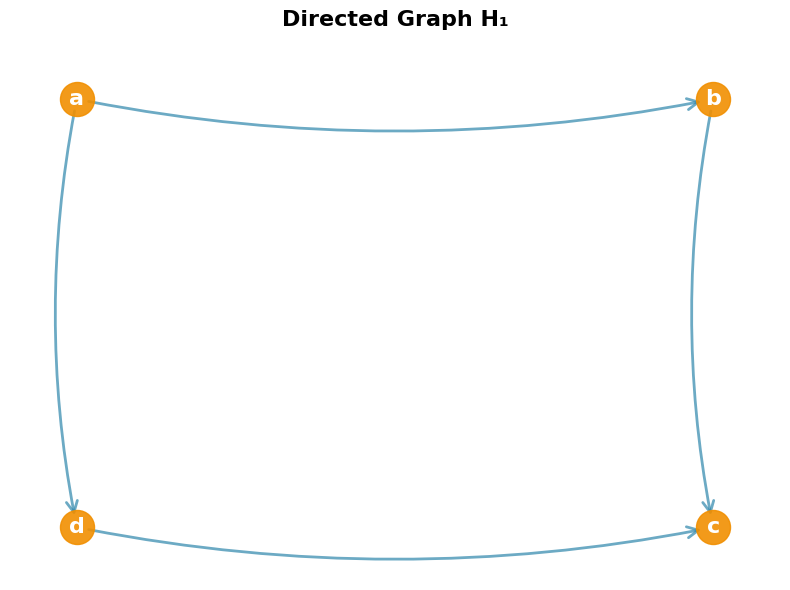


Drawing Directed Graph H₂...


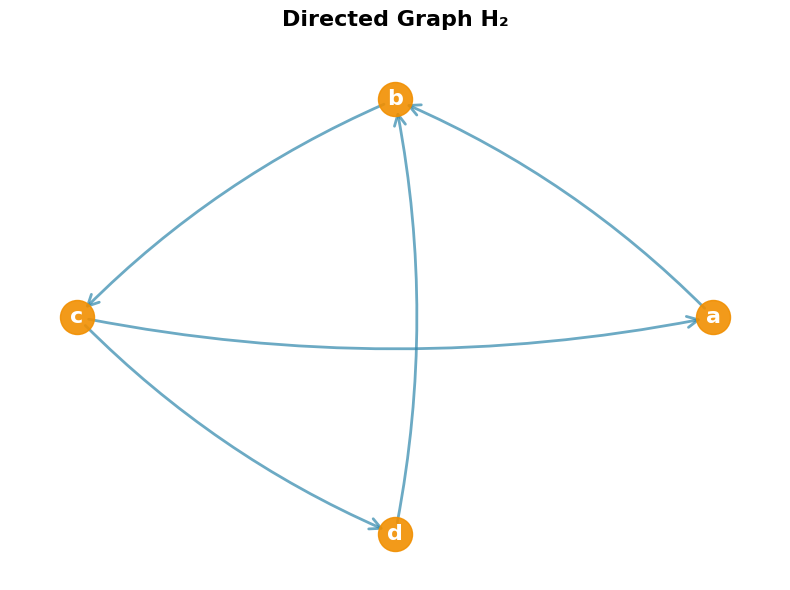


Drawing Directed Graph H₃...


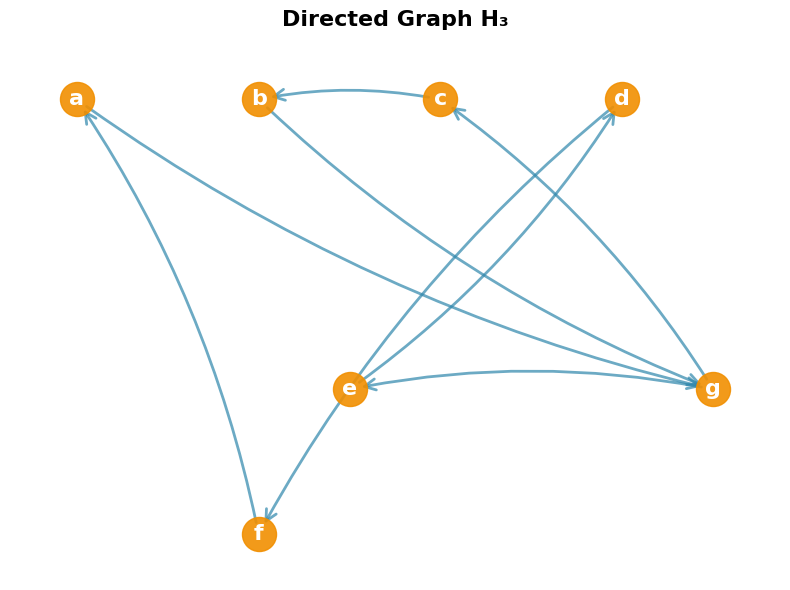


Directed Graph H₁ Analysis:
Weakly connected: Yes
Strongly connected: No

Vertex Degree Details:
Vertex Out-degree In-degree Out - In  
--------------------------------------
a      2          0         2+++++++++
b      1          1         0+++++++++
c      0          2         -2++++++++
d      1          1         0+++++++++

Statistics:
  Start vertices (out-degree - in-degree = 1): None
  End vertices (out-degree - in-degree = -1): None
  Balanced vertices (out-degree = in-degree): ['b', 'd']

🏆 Classification: Neither - No Euler circuit or path

Directed Graph H₂ Analysis:
Weakly connected: Yes
Strongly connected: Yes

Vertex Degree Details:
Vertex Out-degree In-degree Out - In  
--------------------------------------
a      1          1         0+++++++++
b      1          2         -1++++++++
c      2          1         1+++++++++
d      1          1         0+++++++++

Statistics:
  Start vertices (out-degree - in-degree = 1): ['c']
  End vertices (out-degree - in-degree = -

In [15]:
import networkx as nx
import matplotlib.pyplot as plt

# ========== Create three directed graphs ==========

# H₁: Directed cycle graph (all vertices balanced) - Eulerian
H1 = nx.DiGraph()
H1.add_edges_from([('a', 'b'), ('b', 'c'), ('d', 'c'), ('a', 'd')])

# H₂: Directed graph - unbalanced degrees
H2 = nx.DiGraph()
H2.add_edges_from([
    ('a', 'b'), ('b', 'c'), ('c', 'a'), ('d', 'b'),  # cycle
    ('c', 'd')
])

# H₃: Directed graph with Euler path (exactly one start and one end)
H3 = nx.DiGraph()
H3.add_edges_from([
    ('a', 'g'), ('g', 'c'), ('c', 'b'),  
    ('b', 'g'), ('g', 'e'), ('e', 'd'),  
    ('d', 'f'), ('f', 'a')
])

def analyze_directed_euler(graph, name):
    """Analyze Euler circuits and paths in directed graphs"""
    print(f"\n{'='*60}")
    print(f"{name} Analysis:")
    print(f"{'='*60}")
    
    # Check weak connectivity
    is_weakly_connected = nx.is_weakly_connected(graph)
    print(f"Weakly connected: {'Yes' if is_weakly_connected else 'No'}")
    
    # Check strong connectivity
    is_strongly_connected = nx.is_strongly_connected(graph)
    print(f"Strongly connected: {'Yes' if is_strongly_connected else 'No'}")
    
    # Calculate in-degrees and out-degrees
    in_degrees = dict(graph.in_degree())
    out_degrees = dict(graph.out_degree())
    
    print(f"\nVertex Degree Details:")
    print(f"{'Vertex':<6} {'Out-degree':<10} {'In-degree':<9} {'Out - In':<10}")
    print("-" * 38)
    
    balance = {}
    for node in sorted(graph.nodes()):
        diff = out_degrees[node] - in_degrees[node]
        balance[node] = diff
        print(f"{node:<6} {out_degrees[node]:<10} {in_degrees[node]:<9} {diff:+<10}")
    
    # Count start and end vertices
    starts = [v for v, d in balance.items() if d == 1]
    ends = [v for v, d in balance.items() if d == -1]
    balanced = [v for v, d in balance.items() if d == 0]
    
    print(f"\nStatistics:")
    print(f"  Start vertices (out-degree - in-degree = 1): {starts if starts else 'None'}")
    print(f"  End vertices (out-degree - in-degree = -1): {ends if ends else 'None'}")
    print(f"  Balanced vertices (out-degree = in-degree): {balanced if balanced else 'None'}")
    
    # Classification (Euler's theorem for directed graphs)
    if is_strongly_connected and all(d == 0 for d in balance.values()):
        classification = "Eulerian - Has Euler circuit"
        has_circuit = True
        has_path = True
    elif (is_weakly_connected and 
          len(starts) == 1 and len(ends) == 1 and 
          all(abs(d) <= 1 for d in balance.values())):
        classification = "Semi-Eulerian - Has Euler path but no circuit"
        has_circuit = False
        has_path = True
    else:
        classification = "Neither - No Euler circuit or path"
        has_circuit = False
        has_path = False
    
    print(f"\n{'🏆 Classification: ' + classification}")
    
    return classification, has_circuit, has_path, starts, ends

def draw_directed_graph(graph, title):
    """Draw directed graph"""
    plt.figure(figsize=(8, 6))
    
    # Set different layouts for different graphs
    if title == "Directed Graph H₁":
        # H1: Square layout
        pos = {'a': (0, 1), 'b': (1, 1), 'c': (1, 0), 'd': (0, 0)}
    elif title == "Directed Graph H₂":
        # H2: Circular layout
        pos = nx.circular_layout(graph)
        pos = {node: (pos[node][0] * 1.5, pos[node][1] * 1.5) for node in pos}
    else:  # H3
        # H3: Custom layout to show structure
        pos = {
            'a': (0, 1.5), 'b': (1, 1.5), 'c': (2, 1.5),
            'd': (3, 1.5), 'e': (1.5, 0.5), 'f': (1, 0),
            'g': (3.5, 0.5), 'h': (3, -0.5)
        }
    
    # Draw all edges (with arrows)
    nx.draw_networkx_edges(graph, pos, edge_color='#2E86AB', 
                          width=2, alpha=0.7, arrows=True,
                          arrowsize=20, arrowstyle='->',
                          connectionstyle='arc3,rad=0.1')
    
    # Draw vertices
    nx.draw_networkx_nodes(graph, pos, node_color='#F18F01', 
                          node_size=600, alpha=0.9)
    nx.draw_networkx_labels(graph, pos, font_size=16, font_weight='bold',
                           font_color='white')
    
    # Add edge labels (optional, shows direction)
    edge_labels = {(u, v): '' for u, v in graph.edges()}
    
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def print_classification_summary(results):
    """Print classification summary table"""
    print(f"\n{'='*70}")
    print("📊 Classification Summary Table")
    print(f"{'='*70}")
    
    print(f"\n{'Graph':<12} {'Classification':<30} {'Euler Circuit':<14} {'Euler Path':<10}")
    print("-" * 70)
    
    for name, info in results.items():
        cat_short = info['classification'].split(' - ')[0]
        has_circuit = "✓" if info['has_circuit'] else "✗"
        has_path = "✓" if info['has_path'] else "✗"
        print(f"{name:<12} {cat_short:<30} {has_circuit:<14} {has_path:<10}")
    
    print(f"{'='*70}")

# Store results
graphs = [(H1, "Directed Graph H₁"), (H2, "Directed Graph H₂"), (H3, "Directed Graph H₃")]
results = {}


for graph, name in graphs:
    print(f"\nDrawing {name}...")
    draw_directed_graph(graph, name)


for graph, name in graphs:
    classification, has_circuit, has_path, starts, ends = analyze_directed_euler(graph, name)
    results[name] = {
        'classification': classification,
        'has_circuit': has_circuit,
        'has_path': has_path,
        'starts': starts,
        'ends': ends
    }


# Chinese Postman Problem or Route Inspection Problem

The Chinese Postman Problem (CPP) is the problem is to find shortest path or circuity that visits every edge of the graph at least once.  This problem was first introduced by Chinese mathematician Mei-Ko Kwan in the 1960s and has since become an important problem in computer science, transportation planning, and other fields.

Formally, the CPP is defined as follows: Given an undirected weighted graph $G = (V, E)$, where $V$ is the set of vertices and $E$ is the set of edges, find a closed path that traverses each edge of the graph at least once. The path should start and end at the same vertex, and the total length of the path should be minimized.

## If input graph contains Euler Circuit

If input graph contains Euler Circuit, then a solution of the problem is Euler Circuit.

It doesn’t matter whether graph is weighted or unweighted, the Chinese Postman Route is always same as Eulerian Circuit if it exists. In weighted graph the minimum possible weight of Postman tour is sum of all edge weights which we get through Eulerian Circuit. We can’t get a shorter route as we must visit all edges at-least once.

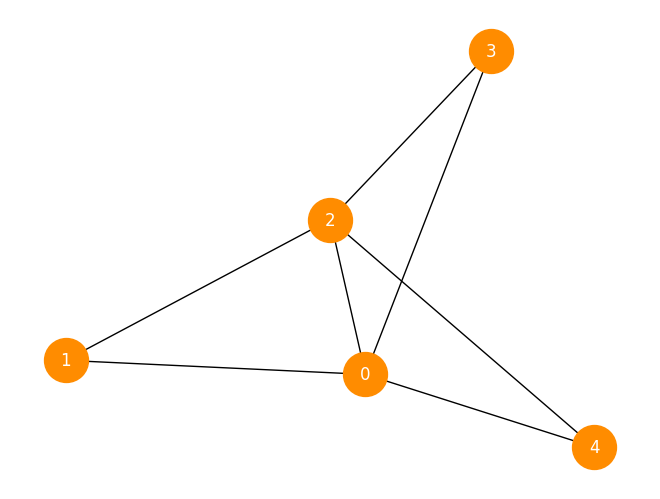

In [8]:
T = nx.Graph([(0, 1), (0, 2), (0, 3), (0, 4), (1, 2), (2, 3), (2, 4)])
nx.draw(
    T, with_labels=True, node_size=1000, font_color="White", node_color="darkorange"
)

In [9]:
# np.random.seed(0) makes the random numbers predictable
# With the seed reset (every time), the same set of numbers will appear every time.
# If the random seed is not reset, different numbers appear with every invocation.

np.random.seed(5); np.random.randint(1, 10, size=5)

array([4, 7, 7, 1, 9])

In [10]:
list(np.random.randint(1, 10, size=5))

[np.int64(5), np.int64(8), np.int64(1), np.int64(1), np.int64(8)]

In [12]:
# Add weights to the graph edges

np.random.seed(2025);
wts = list(np.random.randint(1, 10, size=7))

# list of graph edges

T_edges = [(u, v) for u, v in T.edges()]

# dictionary

att_dict = dict(zip(T_edges, wts))

# Add weights from a dictionary
nx.set_edge_attributes(T, values = att_dict, name = 'weight')

In [13]:
att_dict

{(0, 1): np.int64(3),
 (0, 2): np.int64(9),
 (0, 3): np.int64(4),
 (0, 4): np.int64(4),
 (1, 2): np.int64(1),
 (2, 3): np.int64(7),
 (2, 4): np.int64(9)}

In [14]:
T.edges(data = True)

EdgeDataView([(0, 1, {'weight': np.int64(3)}), (0, 2, {'weight': np.int64(9)}), (0, 3, {'weight': np.int64(4)}), (0, 4, {'weight': np.int64(4)}), (1, 2, {'weight': np.int64(1)}), (2, 3, {'weight': np.int64(7)}), (2, 4, {'weight': np.int64(9)})])

In [15]:
nx.is_eulerian(T)

True

In [16]:
#To get an Eulerian circuit in an undirected graph:
cpp_T=list(nx.eulerian_circuit(T))

# To get the sequence of vertices in an Eulerian circuit:
cpp_vertices = [u for u, v, in cpp_T]

# list of weights on Eulerian circuit
cpp_edges_weights = [T[u][v]['weight'] for (u, v) in cpp_T]

In [17]:
print(f'The Postman Route is {cpp_vertices}.')

print(f'Length of the Chinese Postman Route is {sum(cpp_edges_weights)}.')

The Postman Route is [0, 4, 2, 3, 0, 2, 1].
Length of the Chinese Postman Route is 37.


 ## If input graph does NOT contain Euler Circuit

Algorithm to find shortest closed path or optimal
Chinese postman route in a weighted graph that may
not be Eulerian.

1. If graph is Eulerian, return sum of all edge weights. Else do following steps.
2. Find nodes of odd degree.
3. Find Min distance pairs:

  3.1. Compute all possible pairs of odd degree nodes.

  3.2 Compute the shortest path between each node pair calculated in 3.1.

  3.3 Create a complete graph connecting every node pair in 3.1. with shortest path distance attributes calculated in 3.2.

  3.4. Compute a minimum weight matching of the graph calculated in 3.3.
  (This boils down to determining how to pair the odd nodes such that the sum of the distance between the pairs is as small as possible).
  
  3.5 Augment the original graph with the shortest paths between the node pairs calculated in 3.4.

4. Compute Eulerian Circuit

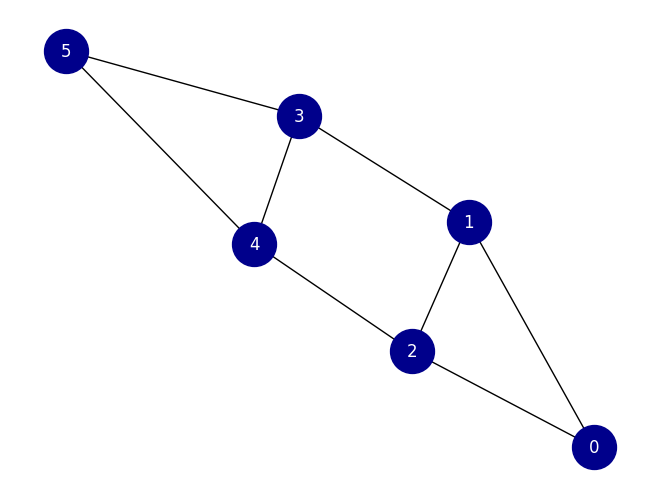

In [18]:
G = nx.Graph([(0, 1), (0, 2), (1, 2), (1, 3), (2, 4), (3, 4), (3, 5), (4, 5)])

G.add_edge(0, 1, weight = 1.0)
G.add_edge(0, 2, weight = 2.0)
G.add_edge(1, 2, weight = 5.0)
G.add_edge(1, 3, weight = 3.0)
G.add_edge(2, 4, weight = 4.0)
G.add_edge(3, 4, weight = 6.0)
G.add_edge(3, 5, weight = 1.0)
G.add_edge(4, 5, weight = 1.0)

nx.draw(
    G, with_labels=True, node_size=1000, font_color="White", node_color="darkblue"
)

**Step 1.** If graph is Eulerian, return sum of all edge weights. Else do following steps.

In [19]:
nx.is_eulerian(G)

False

**Step 2.** Find nodes of odd degree.

In [20]:
G.degree()

DegreeView({0: 2, 1: 3, 2: 3, 3: 3, 4: 3, 5: 2})

In [21]:
# Calculate list of nodes with odd degree
nodes_odd_degree = [v for v, d in G.degree() if d % 2 == 1]

# Preview
nodes_odd_degree

[1, 2, 3, 4]

In [22]:
# Counts
print('Number of nodes of odd degree: {}'.format(len(nodes_odd_degree)))
print('Number of total nodes: {}'.format(len(G.nodes())))

Number of nodes of odd degree: 4
Number of total nodes: 6


**Step 3.** Find Min Distance Pairs

**3.1.** Compute all possible pairs of odd degree nodes.

In [23]:
# Compute all pairs of odd nodes. in a list of tuples
odd_node_pairs = list(itertools.combinations(nodes_odd_degree, 2))

# Preview pairs of odd degree nodes
odd_node_pairs

[(1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]

**3.2.** Compute shortest paths between node pairs

In [24]:
def get_shortest_paths_distances(graph, pairs, edge_weight_name):
    """Compute shortest distance between each pair of nodes in a graph.  Return a dictionary keyed on node pairs (tuples)."""
    distances = {}
    for pair in pairs:
        distances[pair] = nx.dijkstra_path_length(graph, pair[0], pair[1], weight=edge_weight_name)
    return distances

In [25]:
# Compute shortest paths.  Return a dictionary with node pairs keys and a single value equal to shortest path distance.
odd_node_pairs_shortest_paths = get_shortest_paths_distances(G, odd_node_pairs, 'weight')

# Preview
dict(list(odd_node_pairs_shortest_paths.items()))

{(1, 2): 3.0, (1, 3): 3.0, (1, 4): 5.0, (2, 3): 6.0, (2, 4): 4.0, (3, 4): 2.0}

**3.3.** Create Complete Graph

A complete graph is simply a graph where every node is connected to every other node by a unique edge.

create_complete_graph is defined to calculate it.

In [26]:
def create_complete_graph(pair_weights):
    """
    Create a completely connected graph using a list of vertex pairs and the shortest path distances between them
    Parameters:
        pair_weights: list[tuple] from the output of get_shortest_paths_distances
        flip_weights: Boolean. Should we negate the edge attribute in pair_weights?
    """
    g = nx.Graph()
    for k, val in pair_weights.items():
      g.add_edge(k[0], k[1], weight = val)
    return g

In [27]:
# Generate the complete graph
G_odd_complete = create_complete_graph(odd_node_pairs_shortest_paths)

# Counts
print('Number of nodes: {}'.format(len(G_odd_complete.nodes())))
print('Number of edges: {}'.format(len(G_odd_complete.edges())))

Number of nodes: 4
Number of edges: 6


In [28]:
G_odd_complete.edges(data=True)

EdgeDataView([(1, 2, {'weight': 3.0}), (1, 3, {'weight': 3.0}), (1, 4, {'weight': 5.0}), (2, 3, {'weight': 6.0}), (2, 4, {'weight': 4.0}), (3, 4, {'weight': 2.0})])

**3.4.** Compute Minimum Weight Matching

This is the most complex step in the CPP. We need to find the odd degree node pairs whose combined sum (of distance between them) is as small as possible.
This is Minimum Weight Matching problem.

In [29]:
list(nx.algorithms.min_weight_matching(G_odd_complete))

[(1, 2), (4, 3)]

In [30]:
# Compute min weight matching.
# Note: max_weight_matching uses the 'weight' attribute by default as the attribute to maximize.
odd_matching = list(nx.algorithms.min_weight_matching(G_odd_complete))

print('Number of edges in matching: {}'.format(len(odd_matching)))

Number of edges in matching: 2


In [31]:
# Preview of matching
odd_matching

[(1, 2), (4, 3)]

In [32]:
nx.shortest_path(G, 1, 2, weight='weight')

[1, 0, 2]

**3.5.** Augment the original graph

In [33]:
def add_augmenting_path_to_graph(graph, min_weight_pairs):
    """
    Add the min weight matching edges to the original graph
    Parameters:
        graph: NetworkX graph (original graph from trailmap)
        min_weight_pairs: list[tuples] of node pairs from min weight matching
    Returns:
        augmented NetworkX graph
    """

    # We need to make the augmented graph a MultiGraph so we can add parallel edges
    graph_aug = nx.MultiGraph(graph.copy())
    for pair in min_weight_pairs:
      aug_path = nx.shortest_path(graph, pair[0], pair[1], weight='weight')
      aug_path_pairs = list(zip(aug_path[:-1], aug_path[1:]))
      for edg in aug_path_pairs:
        graph_aug.add_edge(edg[0], edg[1],
                         weight = graph[edg[0]][edg[1]]['weight'])
    return graph_aug

In [34]:
# Create augmented graph: add the min weight matching edges to g
G_aug = add_augmenting_path_to_graph(G, odd_matching)

# Counts
print('Number of edges in original graph: {}'.format(len(G.edges())))
print('Number of edges in augmented graph: {}'.format(len(G_aug.edges())))

Number of edges in original graph: 8
Number of edges in augmented graph: 12


In [35]:
G_aug.edges(data=True)

MultiEdgeDataView([(0, 1, {'weight': 1.0}), (0, 1, {'weight': 1.0}), (0, 2, {'weight': 2.0}), (0, 2, {'weight': 2.0}), (1, 2, {'weight': 5.0}), (1, 3, {'weight': 3.0}), (2, 4, {'weight': 4.0}), (3, 4, {'weight': 6.0}), (3, 5, {'weight': 1.0}), (3, 5, {'weight': 1.0}), (4, 5, {'weight': 1.0}), (4, 5, {'weight': 1.0})])

In [36]:
euler_circuit = list(nx.eulerian_circuit(G_aug))

In [37]:
euler_circuit

[(0, 2),
 (2, 4),
 (4, 5),
 (5, 3),
 (3, 5),
 (5, 4),
 (4, 3),
 (3, 1),
 (1, 2),
 (2, 0),
 (0, 1),
 (1, 0)]

In [38]:
euler_circuit_weights = [G_aug[u][v][0]['weight'] for (u, v) in euler_circuit]
euler_circuit_weights

[2.0, 4.0, 1.0, 1.0, 1.0, 1.0, 6.0, 3.0, 5.0, 2.0, 1.0, 1.0]

In [39]:
print('Total length of Eulerian circuit: {}'.format(sum(euler_circuit_weights)))

Total length of Eulerian circuit: 28.0


# Exercise 2.

1. Greate an undirected weighted graph from a txt.file (cpp_graph_1.txt, cpp_graph_2.txt)
2. Find if this graph eulerian or not?
3. Solve Chinese Postman Problem (CPP) for the graph.
4. Print the edges you add to the augumented graph.
5. Return the euler circuit and the total lenght of Eulerian circuit.
6. Send your code for each graph in MS Teams chat messenger.

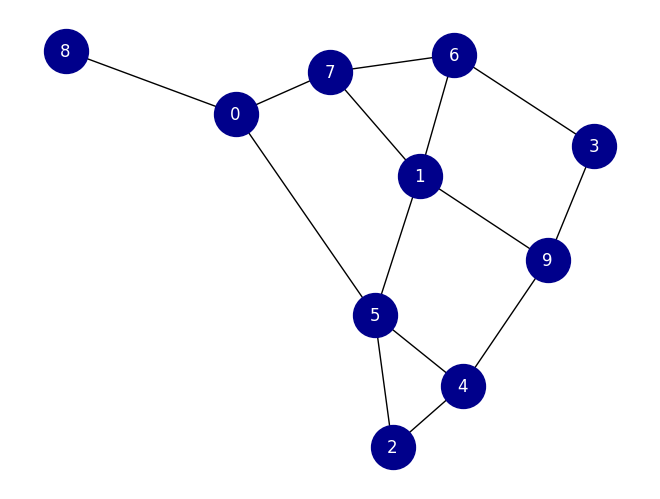

In [2]:
G = nx.Graph([(0, 5), (1, 6), (1, 5), (2, 5), (2, 4), (3, 6), (4, 5), (8, 0), (0, 7), (1, 7), (6, 7), (4, 9), (3, 9), (1, 9)])

G.add_edge(0, 5, weight = 343)
G.add_edge(1, 6, weight = 954)
G.add_edge(1, 5, weight = 879)
G.add_edge(2, 5, weight = 1054)
G.add_edge(2, 4, weight = 1364)
G.add_edge(3, 6, weight = 433)
G.add_edge(4, 5, weight = 1106)
G.add_edge(8, 0, weight = 464)
G.add_edge(0, 7, weight = 1435)
G.add_edge(1, 7, weight = 811)
G.add_edge(6, 7, weight = 837)
G.add_edge(4, 9, weight = 766)
G.add_edge(3, 9, weight = 1053)
G.add_edge(1, 9, weight = 524)

nx.draw(
    G, with_labels=True, node_size=1000, font_color="White", node_color="darkblue"
)

In [3]:
nx.is_eulerian(G)

False

In [4]:
G.degree()

DegreeView({0: 3, 5: 4, 1: 4, 6: 3, 2: 2, 4: 3, 3: 2, 8: 1, 7: 3, 9: 3})

In [5]:
# Calculate list of nodes with odd degree
nodes_odd_degree = [v for v, d in G.degree() if d % 2 == 1]

# Preview
nodes_odd_degree

[0, 6, 4, 8, 7, 9]

In [6]:
# Counts
print('Number of nodes of odd degree: {}'.format(len(nodes_odd_degree)))
print('Number of total nodes: {}'.format(len(G.nodes())))

Number of nodes of odd degree: 6
Number of total nodes: 10


In [7]:
# Compute all pairs of odd nodes. in a list of tuples
odd_node_pairs = list(itertools.combinations(nodes_odd_degree, 2))

# Preview pairs of odd degree nodes
odd_node_pairs

[(0, 6),
 (0, 4),
 (0, 8),
 (0, 7),
 (0, 9),
 (6, 4),
 (6, 8),
 (6, 7),
 (6, 9),
 (4, 8),
 (4, 7),
 (4, 9),
 (8, 7),
 (8, 9),
 (7, 9)]

In [8]:
def get_shortest_paths_distances(graph, pairs, edge_weight_name):
    """Compute shortest distance between each pair of nodes in a graph.  Return a dictionary keyed on node pairs (tuples)."""
    distances = {}
    for pair in pairs:
        distances[pair] = nx.dijkstra_path_length(graph, pair[0], pair[1], weight=edge_weight_name)
    return distances

In [10]:
# Compute shortest paths.  Return a dictionary with node pairs keys and a single value equal to shortest path distance.
odd_node_pairs_shortest_paths = get_shortest_paths_distances(G, odd_node_pairs, 'weight')

# Preview
dict(list(odd_node_pairs_shortest_paths.items()))

{(0, 6): 2176,
 (0, 4): 1449,
 (0, 8): 464,
 (0, 7): 1435,
 (0, 9): 1746,
 (6, 4): 2244,
 (6, 8): 2640,
 (6, 7): 837,
 (6, 9): 1478,
 (4, 8): 1913,
 (4, 7): 2101,
 (4, 9): 766,
 (8, 7): 1899,
 (8, 9): 2210,
 (7, 9): 1335}

In [11]:
def create_complete_graph(pair_weights):
    """
    Create a completely connected graph using a list of vertex pairs and the shortest path distances between them
    Parameters:
        pair_weights: list[tuple] from the output of get_shortest_paths_distances
        flip_weights: Boolean. Should we negate the edge attribute in pair_weights?
    """
    g = nx.Graph()
    for k, val in pair_weights.items():
      g.add_edge(k[0], k[1], weight = val)
    return g

In [12]:
# Generate the complete graph
G_odd_complete = create_complete_graph(odd_node_pairs_shortest_paths)

# Counts
print('Number of nodes: {}'.format(len(G_odd_complete.nodes())))
print('Number of edges: {}'.format(len(G_odd_complete.edges())))

Number of nodes: 6
Number of edges: 15


In [13]:
G_odd_complete.edges(data=True)

EdgeDataView([(0, 6, {'weight': 2176}), (0, 4, {'weight': 1449}), (0, 8, {'weight': 464}), (0, 7, {'weight': 1435}), (0, 9, {'weight': 1746}), (6, 4, {'weight': 2244}), (6, 8, {'weight': 2640}), (6, 7, {'weight': 837}), (6, 9, {'weight': 1478}), (4, 8, {'weight': 1913}), (4, 7, {'weight': 2101}), (4, 9, {'weight': 766}), (8, 7, {'weight': 1899}), (8, 9, {'weight': 2210}), (7, 9, {'weight': 1335})])

In [15]:
list(nx.algorithms.min_weight_matching(G_odd_complete))

[(4, 9), (6, 7), (8, 0)]

In [16]:
# Compute min weight matching.
# Note: max_weight_matching uses the 'weight' attribute by default as the attribute to maximize.
odd_matching = list(nx.algorithms.min_weight_matching(G_odd_complete))

print('Number of edges in matching: {}'.format(len(odd_matching)))

Number of edges in matching: 3


In [17]:
# Preview of matching
odd_matching

[(4, 9), (6, 7), (8, 0)]

In [18]:
nx.shortest_path(G, 1, 2, weight='weight')

[1, 5, 2]

In [19]:
def add_augmenting_path_to_graph(graph, min_weight_pairs):
    """
    Add the min weight matching edges to the original graph
    Parameters:
        graph: NetworkX graph (original graph from trailmap)
        min_weight_pairs: list[tuples] of node pairs from min weight matching
    Returns:
        augmented NetworkX graph
    """

    # We need to make the augmented graph a MultiGraph so we can add parallel edges
    graph_aug = nx.MultiGraph(graph.copy())
    for pair in min_weight_pairs:
      aug_path = nx.shortest_path(graph, pair[0], pair[1], weight='weight')
      aug_path_pairs = list(zip(aug_path[:-1], aug_path[1:]))
      for edg in aug_path_pairs:
        graph_aug.add_edge(edg[0], edg[1],
                         weight = graph[edg[0]][edg[1]]['weight'])
    return graph_aug

In [20]:
# Create augmented graph: add the min weight matching edges to g
G_aug = add_augmenting_path_to_graph(G, odd_matching)

# Counts
print('Number of edges in original graph: {}'.format(len(G.edges())))
print('Number of edges in augmented graph: {}'.format(len(G_aug.edges())))

Number of edges in original graph: 14
Number of edges in augmented graph: 17


In [21]:
G_aug.edges(data=True)

MultiEdgeDataView([(0, 5, {'weight': 343}), (0, 8, {'weight': 464}), (0, 8, {'weight': 464}), (0, 7, {'weight': 1435}), (5, 1, {'weight': 879}), (5, 2, {'weight': 1054}), (5, 4, {'weight': 1106}), (1, 6, {'weight': 954}), (1, 7, {'weight': 811}), (1, 9, {'weight': 524}), (6, 3, {'weight': 433}), (6, 7, {'weight': 837}), (6, 7, {'weight': 837}), (2, 4, {'weight': 1364}), (4, 9, {'weight': 766}), (4, 9, {'weight': 766}), (3, 9, {'weight': 1053})])

In [22]:
euler_circuit = list(nx.eulerian_circuit(G_aug))

In [23]:
euler_circuit

[(0, 8),
 (8, 0),
 (0, 7),
 (7, 6),
 (6, 7),
 (7, 1),
 (1, 9),
 (9, 4),
 (4, 2),
 (2, 5),
 (5, 4),
 (4, 9),
 (9, 3),
 (3, 6),
 (6, 1),
 (1, 5),
 (5, 0)]

In [24]:
euler_circuit_weights = [G_aug[u][v][0]['weight'] for (u, v) in euler_circuit]
euler_circuit_weights

[464,
 464,
 1435,
 837,
 837,
 811,
 524,
 766,
 1364,
 1054,
 1106,
 766,
 1053,
 433,
 954,
 879,
 343]

In [26]:
print('Total length of Eulerian circuit: {}'.format(sum(euler_circuit_weights)))

Total length of Eulerian circuit: 14090


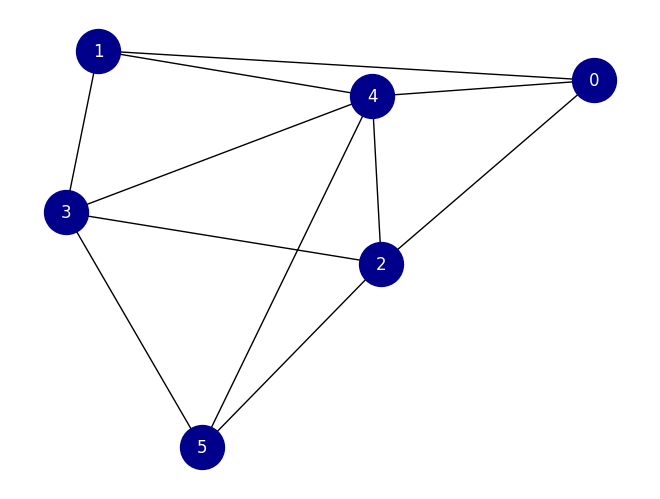

In [28]:
G = nx.Graph([(2, 4), (3, 5), (3, 4), (4, 5), (2, 3), (1, 4), (1, 3), (0, 2), (0, 1), (4, 0), (5, 2)])

G.add_edge(2, 4, weight = 33)
G.add_edge(3, 5, weight = 12)
G.add_edge(3, 4, weight = 5)
G.add_edge(4, 5, weight = 1)
G.add_edge(2, 3, weight = 20)
G.add_edge(1, 4, weight = 10)
G.add_edge(1, 3, weight = 50)
G.add_edge(0, 2, weight = 20)
G.add_edge(0, 1, weight = 10)
G.add_edge(4, 0, weight = 12)
G.add_edge(5, 2, weight = 22)

nx.draw(
    G, with_labels=True, node_size=1000, font_color="White", node_color="darkblue"
)

In [29]:
nx.is_eulerian(G)

False

In [30]:
G.degree()

DegreeView({2: 4, 4: 5, 3: 4, 5: 3, 1: 3, 0: 3})

In [31]:
# Calculate list of nodes with odd degree
nodes_odd_degree = [v for v, d in G.degree() if d % 2 == 1]

# Preview
nodes_odd_degree

[4, 5, 1, 0]

In [32]:
# Counts
print('Number of nodes of odd degree: {}'.format(len(nodes_odd_degree)))
print('Number of total nodes: {}'.format(len(G.nodes())))

Number of nodes of odd degree: 4
Number of total nodes: 6


In [33]:
# Compute all pairs of odd nodes. in a list of tuples
odd_node_pairs = list(itertools.combinations(nodes_odd_degree, 2))

# Preview pairs of odd degree nodes
odd_node_pairs

[(4, 5), (4, 1), (4, 0), (5, 1), (5, 0), (1, 0)]

In [34]:
def get_shortest_paths_distances(graph, pairs, edge_weight_name):
    """Compute shortest distance between each pair of nodes in a graph.  Return a dictionary keyed on node pairs (tuples)."""
    distances = {}
    for pair in pairs:
        distances[pair] = nx.dijkstra_path_length(graph, pair[0], pair[1], weight=edge_weight_name)
    return distances

In [35]:
# Compute shortest paths.  Return a dictionary with node pairs keys and a single value equal to shortest path distance.
odd_node_pairs_shortest_paths = get_shortest_paths_distances(G, odd_node_pairs, 'weight')

# Preview
dict(list(odd_node_pairs_shortest_paths.items()))

{(4, 5): 1, (4, 1): 10, (4, 0): 12, (5, 1): 11, (5, 0): 13, (1, 0): 10}

In [36]:
def create_complete_graph(pair_weights):
    """
    Create a completely connected graph using a list of vertex pairs and the shortest path distances between them
    Parameters:
        pair_weights: list[tuple] from the output of get_shortest_paths_distances
        flip_weights: Boolean. Should we negate the edge attribute in pair_weights?
    """
    g = nx.Graph()
    for k, val in pair_weights.items():
      g.add_edge(k[0], k[1], weight = val)
    return g

In [37]:
# Generate the complete graph
G_odd_complete = create_complete_graph(odd_node_pairs_shortest_paths)

# Counts
print('Number of nodes: {}'.format(len(G_odd_complete.nodes())))
print('Number of edges: {}'.format(len(G_odd_complete.edges())))

Number of nodes: 4
Number of edges: 6


In [38]:
G_odd_complete.edges(data=True)

EdgeDataView([(4, 5, {'weight': 1}), (4, 1, {'weight': 10}), (4, 0, {'weight': 12}), (5, 1, {'weight': 11}), (5, 0, {'weight': 13}), (1, 0, {'weight': 10})])

In [39]:
list(nx.algorithms.min_weight_matching(G_odd_complete))

[(1, 0), (5, 4)]

In [40]:
# Compute min weight matching.
# Note: max_weight_matching uses the 'weight' attribute by default as the attribute to maximize.
odd_matching = list(nx.algorithms.min_weight_matching(G_odd_complete))

print('Number of edges in matching: {}'.format(len(odd_matching)))

Number of edges in matching: 2


In [41]:
# Preview of matching
odd_matching

[(1, 0), (5, 4)]

In [42]:
nx.shortest_path(G, 1, 2, weight='weight')

[1, 0, 2]

In [43]:
def add_augmenting_path_to_graph(graph, min_weight_pairs):
    """
    Add the min weight matching edges to the original graph
    Parameters:
        graph: NetworkX graph (original graph from trailmap)
        min_weight_pairs: list[tuples] of node pairs from min weight matching
    Returns:
        augmented NetworkX graph
    """

    # We need to make the augmented graph a MultiGraph so we can add parallel edges
    graph_aug = nx.MultiGraph(graph.copy())
    for pair in min_weight_pairs:
      aug_path = nx.shortest_path(graph, pair[0], pair[1], weight='weight')
      aug_path_pairs = list(zip(aug_path[:-1], aug_path[1:]))
      for edg in aug_path_pairs:
        graph_aug.add_edge(edg[0], edg[1],
                         weight = graph[edg[0]][edg[1]]['weight'])
    return graph_aug

In [44]:
# Create augmented graph: add the min weight matching edges to g
G_aug = add_augmenting_path_to_graph(G, odd_matching)

# Counts
print('Number of edges in original graph: {}'.format(len(G.edges())))
print('Number of edges in augmented graph: {}'.format(len(G_aug.edges())))

Number of edges in original graph: 11
Number of edges in augmented graph: 13


In [45]:
G_aug.edges(data=True)

MultiEdgeDataView([(2, 4, {'weight': 33}), (2, 3, {'weight': 20}), (2, 0, {'weight': 20}), (2, 5, {'weight': 22}), (4, 3, {'weight': 5}), (4, 5, {'weight': 1}), (4, 5, {'weight': 1}), (4, 1, {'weight': 10}), (4, 0, {'weight': 12}), (3, 5, {'weight': 12}), (3, 1, {'weight': 50}), (1, 0, {'weight': 10}), (1, 0, {'weight': 10})])

In [46]:
euler_circuit = list(nx.eulerian_circuit(G_aug))

In [47]:
euler_circuit

[(2, 5),
 (5, 3),
 (3, 1),
 (1, 0),
 (0, 1),
 (1, 4),
 (4, 5),
 (5, 4),
 (4, 0),
 (0, 2),
 (2, 3),
 (3, 4),
 (4, 2)]

In [48]:
euler_circuit_weights = [G_aug[u][v][0]['weight'] for (u, v) in euler_circuit]
euler_circuit_weights

[22, 12, 50, 10, 10, 10, 1, 1, 12, 20, 20, 5, 33]

In [49]:
print('Total length of Eulerian circuit: {}'.format(sum(euler_circuit_weights)))

Total length of Eulerian circuit: 206
